In [1]:
import numpy as np
from matplotlib import pyplot as plt

/home/konstantinos/miniconda3/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
def update_centroids(X,k,labels):
    ncol = X.shape[1]
    centroids = np.zeros(shape = (k,ncol))
    for cluster in range(k):
        centroids[cluster,:] = np.mean(X[labels == cluster,:],axis =0)
    return(centroids)

    

In [3]:
def mahalanobis_distance(point1,point2):
    import numpy as np
    from scipy.linalg import sqrtm

     
    dev = (point1 - point2)
    dev_transpose = dev.T
    cov = np.cov(X, rowvar=False)
    cov_inverse = np.linalg.inv(cov)
    
    mah_dist = np.sqrt(np.dot(np.dot(dev, cov_inverse), dev.T))
    return(mah_dist)
def compute_distances_from_centroids_with_mahalanobis(X, centroids):  
    nrow = X.shape[0]  
    
    mah_dist = np.zeros(shape=(nrow,centroids.shape[0]))
    for i, centroid in enumerate(centroids):
        #a = np.apply_along_axis(mahalanobis_distance, axis=1, arr = X, point2 = centroid)
        mah_dist[:,i] = np.apply_along_axis(mahalanobis_distance, axis=1, arr = X, point2 = centroid)
    labels = np.argmin(mah_dist, axis = 1)
    #return(eudist)
    return(labels)

In [4]:
def manhatan_distance(point1,point2):
    import numpy as np
    dist = 0
    for i in range(len(point1)):
        dist = dist + abs(point1[i] - point2[i])
    return(dist)
    

def compute_distances_from_centroids_with_manhatan(X, centroids):  
    nrow = X.shape[0]
    manh_dist = np.zeros(shape=(nrow,centroids.shape[0]))
    for i, centroid in enumerate(centroids):
        #a = np.apply_along_axis(mahalanobis_distance, axis=1, arr = X, point2 = centroid)
        manh_dist[:,i] = np.apply_along_axis(manhatan_distance, axis=1, arr = X, point2 = centroid)
    labels = np.argmin(manh_dist, axis = 1)
    #return(eudist)
    return(labels)

In [5]:
def compute_distances_from_centroids_with_euclidean(X,centroids):
    from scipy.spatial.distance import cdist
    eudist = cdist(X, centroids, metric='euclidean')
    labels = np.argmin(eudist, axis = 1)
    #return(eudist)
    return(labels)

In [6]:
def kmeans(X,k,max_iterations, distance):
    from sklearn.metrics import silhouette_score
    import time
    start_time = time.time()
    
    minimums = np.min(X,axis = 0)
    maximums = np.max(X, axis = 0)
    nrow, ncol = X.shape
    iteration = 0
    
    centroids = np.zeros(shape = (k,ncol))
    for i in range(k):
        centroids[i,:] = np.random.uniform(minimums, maximums, size=(1,ncol))


    if distance == 'euclidean':
        while iteration <= max_iterations:
            labels = compute_distances_from_centroids_with_euclidean(X, centroids)
            new_centroids = update_centroids(X,k,labels)
            if np.array_equal(new_centroids, centroids):
                #print('{} iterations completed in total.'.format(iteration))
                break
            else:
                centroids = new_centroids
                #print(iteration)
                iteration+=1
    elif distance == 'manhattan':
        while iteration <= max_iterations:
            labels = compute_distances_from_centroids_with_manhatan(X, centroids)
            new_centroids = update_centroids(X,k,labels)
            if np.array_equal(new_centroids, centroids):
                #print('{} iterations completed in total.'.format(iteration))
                break
            else:
                centroids = new_centroids
                #print(iteration)
                iteration+=1
    
    elif distance == 'mahalanobis':
        while iteration <= max_iterations:
            labels = compute_distances_from_centroids_with_mahalanobis(X, centroids)
            new_centroids = update_centroids(X,k,labels)
            if np.array_equal(new_centroids, centroids):
                #print('{} iterations completed in total.'.format(iteration))
                break
            else:
                centroids = new_centroids
                #print(iteration)
                iteration+=1
    else:
        raise ValueError('Input Error. Distance should be Euclidean, manhattan or mahalanobis')
    


    score = silhouette_score(X, labels)
    end_time = time.time()
    run_time = end_time - start_time
    
    #print('The silhouette score is : {:.2f}'.format(score))
    #print('Clustering took {:.2f} seconds.'.format(run_time))
    return(centroids,labels, score)

[]

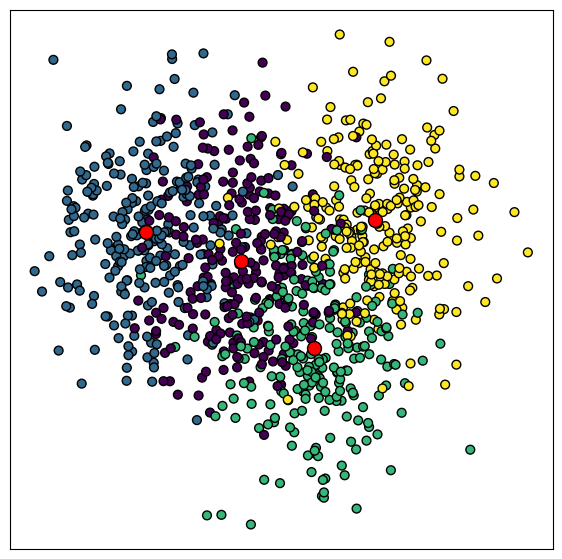

In [7]:
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=1000,n_features=10,centers=4,cluster_std=3.0,random_state=0)
#X = np.random.rand(1000, 2)
k_means_result = kmeans(X,4,50,'manhattan')
centroids = k_means_result[0]
k_means_labels = k_means_result[1]
from matplotlib import pyplot as plt

   

#Plot the results
fig, ax = plt.subplots(1,1,figsize = (7, 7))

ax.scatter(X[:,0], X[:,1], marker = 'o', cmap='viridis', edgecolors='k', c = k_means_labels, s=40)
ax.scatter(centroids[:,0], centroids[:,1],marker='o', c = 'red', s=100,edgecolors='black')
ax.set_xticks([])
ax.set_yticks([])

In [8]:
import numpy as np
def initialize_gmm_with_kmeans(X, n_components):
    n_samples, n_features = X.shape
    
    means, labels = kmeans(X,n_components,50,'euclidean')[:2]
    
    weights = np.zeros(n_components)
    covariances = np.zeros((n_components, n_features, n_features))

    for component in range(n_components):
        cluster = X[labels == component,:]
        weights[component] = cluster.shape[0] / n_samples
        covariances[component] = np.cov(cluster.T)
    
    return(weights, means, covariances)

def initialize_gmm(X, n_components):
    n_samples, n_features = X.shape
    
    # Initialize weights
    weights = np.ones(n_components) / n_components
    
    # Initialize means randomly
    # This step randomly distributes samples to components
    random_indices = np.random.choice(n_samples, n_components, replace=False)
    means = X[random_indices]
    
    # Initialize covariances
    # I start by assuming equal covariance matrices for all comonents
    covariances = np.zeros((n_components, n_features, n_features))
    for k in range(n_components):
        covariances[k] = np.cov(X.T) 
    
    return weights, means, covariances
#############################################################################
def expectation_step(X,k,weights,means, covariances):
    from scipy.stats import multivariate_normal

    nrow, ncol = X.shape
    
    
    #Expectation step
    #Compute the responsibilities
    responsibilities = np.zeros((nrow, k))
    for component in range(k):
        #covariance_array = mean_and_covariance_matrix[1:,:]
        responsibilities[:,component] = weights[component] * multivariate_normal.pdf(X,mean=means[component], cov=covariances[component])
    responsibilities = responsibilities / responsibilities.sum(axis=1, keepdims=True)
    return(responsibilities)

def maximization_step(X,k,responsibilities):
        nrow, ncol = X.shape
        #Maximization Step
        #in this step the covariance matrix the mean the weights are updatedbased on the responsibilities computed on the expectation step
        N = nrow
        Nk = responsibilities.sum(axis=0)
        responsibilities_times_datapoins_sum = np.dot(responsibilities.T, X) #here each datapoint is multiplied by each responsibility and I get the sum

        #Update weights
        weights = Nk / N #An 1 by 3 array where each entryrepresents the πκ (weight) of the component
        #Update means
        means = responsibilities_times_datapoins_sum / Nk.reshape((k,1)) 

        #Update covariances
        covariances = np.zeros((k, ncol, ncol))

        for component in range(k):
        
            mean = means[component]
            dif_from_mean = X - mean
            k_specific_responsibilities = responsibilities[:,component]

            component_specific_cov = np.dot(k_specific_responsibilities * dif_from_mean.T , dif_from_mean)
            covariances[component] = component_specific_cov / Nk[component]
        return(means, weights, covariances)

In [9]:
def mixture_of_gausians(X,k,init,iterations):

    import numpy as np
    from scipy.stats import multivariate_normal
    from sklearn.metrics import silhouette_score
    log_likelihood = 0
    likelihood = 0
    its = 0 
    it = 0
    nrow, ncol = X.shape

    if init == 'random':
        weights, means, covariances = initialize_gmm(X,k)
    elif init == 'kmeans':
        weights, means, covariances = initialize_gmm_with_kmeans(X,k)
    else:
        raise ValueError('Input Error. Init should be random or kmeans.')

    log_likelihood = 0
    likelihood = 0
    its = 0 
    it = 0
    while it <iterations:
        responsibilities = expectation_step(X,k,weights,means, covariances)
        means,weights, covariances = maximization_step(X,k,responsibilities)
        it+=1
        
        '''for component in range(k):
            likelihood = weights[component] * multivariate_normal.pdf(X[component], mean=means[component], cov=covariances[component])
            likelihood += likelihood
        updated_log_likelihood = np.log(likelihood)
        if np.abs(updated_log_likelihood - log_likelihood) < 0.00001:
            break
        else:
            log_likelihood = updated_log_likelihood
            its +=1'''
    
    labels = np.argmax(responsibilities,axis = 1)
    
    centroids = np.zeros(shape=(k, ncol))
    for i in range(k):
        centroids[i,:] = np.mean(X[labels==i,:], axis = 0)

    score = silhouette_score(X, labels)
        
    return(centroids, labels, score)

In [10]:
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=1000,n_features=10,centers=4,cluster_std=3.0,random_state=78)

0.36729743282152716


[]

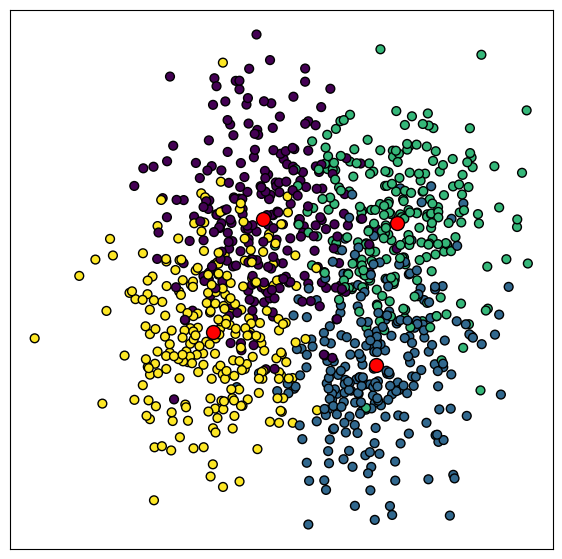

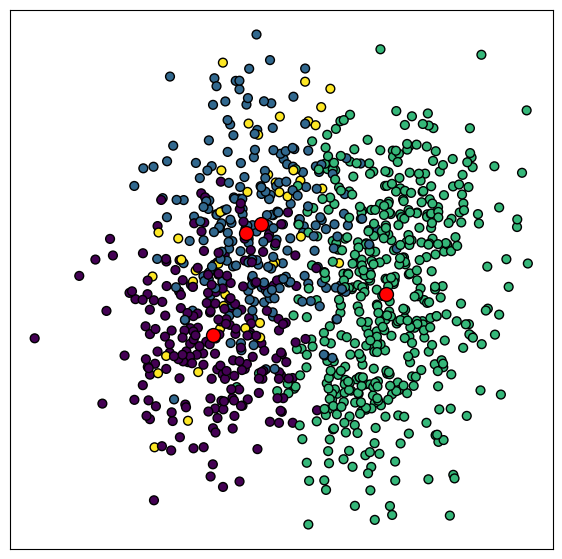

In [11]:

#X = np.random.rand(1000, 2)
k_means_result = kmeans(X,4,50,'manhattan')
centroids = k_means_result[0]
k_means_labels = k_means_result[1]
from matplotlib import pyplot as plt

   

#Plot the results
fig, ax = plt.subplots(1,1,figsize = (7, 7))

ax.scatter(X[:,0], X[:,1], marker = 'o', cmap='viridis', edgecolors='k', c = k_means_labels, s=40)
ax.scatter(centroids[:,0], centroids[:,1],marker='o', c = 'red', s=100,edgecolors='black')
ax.set_xticks([])
ax.set_yticks([])


gmm_results = mixture_of_gausians(X,4,init= 'random',iterations=1000)
gmm_centroids, gmm_labels , gmm_score= gmm_results
print(gmm_score)
###Plot the result

from matplotlib import pyplot as plt

fig, ax = plt.subplots(1,1,figsize = (7, 7))

ax.scatter(X[:,0], X[:,1], marker = 'o', cmap='viridis', edgecolors='k', c = gmm_labels, s=40)

ax.scatter(gmm_centroids[:,0], gmm_centroids[:,1],marker='o', c = 'red', s=100,edgecolors='black')

ax.set_xticks([])
ax.set_yticks([])

In [19]:
scores = np.zeros(shape=(5,3))
for i in range(1,6):
    from sklearn.datasets import make_blobs
    std = i
    row = i -1
    print(row)
    print(i)
    X, y = make_blobs(n_samples=1000,n_features=10,centers=4,cluster_std=std,random_state=78)

    #
    random_gmm_results = mixture_of_gausians(X,4,init= 'random',iterations=1000)
    random_gmm_centroids, random_gmm_labels , random_gmm_score= gmm_results
    #
    kmeans_gmm_results = mixture_of_gausians(X,4,init= 'random',iterations=1000)
    kmeans_gmm_centroids, kmeans_gmm_labels, kmeans_gmm_score = kmeans_gmm_results
    #
    kmeans_results = kmeans(X,4,50,distance='manhattan')
    kmeans_centroids, kmeans_labels, kmeans_score = kmeans_results
    scores[(i-1),:] = [random_gmm_score,kmeans_gmm_score, kmeans_score]


0
1
1
2
2
3
3
4
4
5


In [22]:


#
random_gmm_results = mixture_of_gausians(X,3,init= 'random',iterations=1000)
random_gmm_centroids, random_gmm_labels , random_gmm_score= gmm_results
#
kmeans_gmm_results = mixture_of_gausians(X,3,init= 'random',iterations=1000)
kmeans_gmm_centroids, kmeans_gmm_labels, kmeans_gmm_score = kmeans_gmm_results
#
kmeans_results = kmeans(X,3,50,distance='euclidean')
kmeans_centroids, kmeans_labels, kmeans_score = kmeans_results

def plot_results(X,centroids,labels):
    from matplotlib import pyplot as plt

    fig, ax = plt.subplots(1,1,figsize = (7, 7))

    ax.scatter(X[:,0], X[:,1], marker = 'o', cmap='viridis', edgecolors='k', c = labels, s=40)

    ax.scatter(centroids[:,0], centroids[:,1],marker='o', c = 'red', s=100,edgecolors='black')

    ax.set_xticks([])
    ax.set_yticks([])

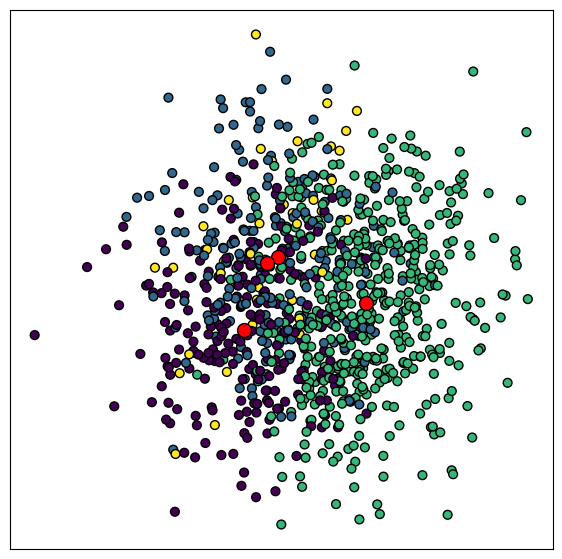

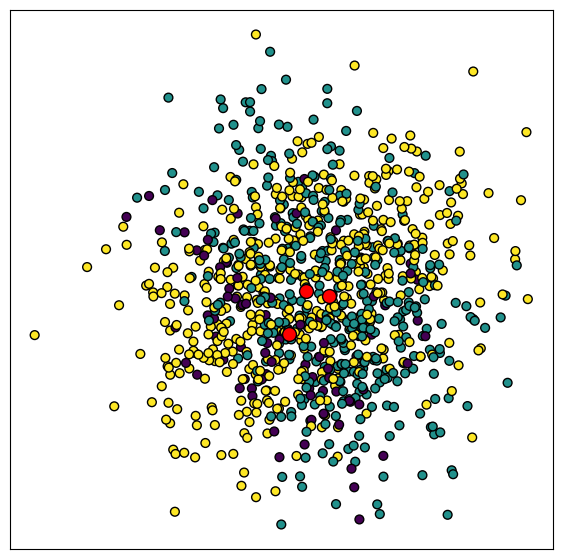

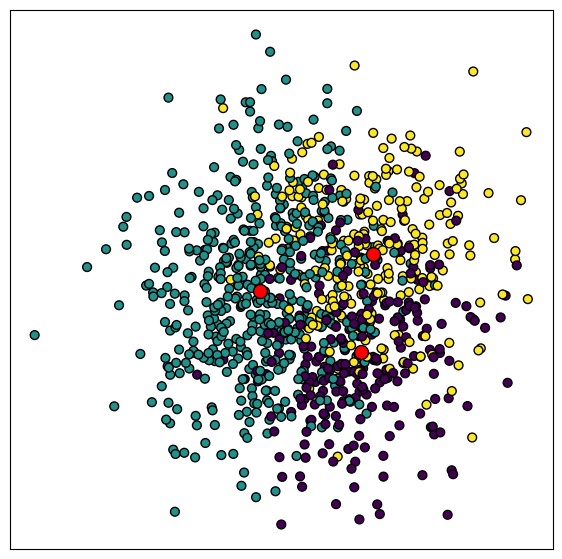

In [23]:
plot_results(X,random_gmm_centroids,random_gmm_labels)
plot_results(X,kmeans_gmm_centroids,kmeans_gmm_labels)
plot_results(X,kmeans_centroids,kmeans_labels)

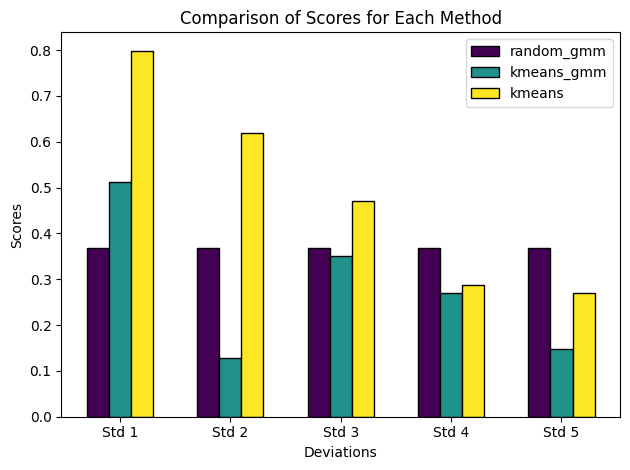

In [24]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

models = ['random_gmm', 'kmeans_gmm', 'kmeans']
n_std, n_models = scores.shape

# Set the bar width
bar_width = 0.2


r = np.arange(n_std)


fig, ax = plt.subplots()


colors = cm.viridis(np.linspace(0, 1, n_models))


for i in range(n_models):
    bar_positions = r + i * bar_width
    ax.bar(bar_positions, scores[:, i], width=bar_width, label=models[i], color=colors[i], edgecolor='black')

# Labeling the axes and the title
ax.set_xlabel('Deviations')
ax.set_ylabel('Scores')
ax.set_title('Comparison of Scores for Each Method')

# Adding the legend
ax.legend()


ax.set_xticks(r + bar_width * (n_models - 1) / 2)
ax.set_xticklabels([f'Std {i+1}' for i in range(n_std)])

plt.tight_layout()
plt.show()



In [ ]:
scores[0,1]

0.0